In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import skew, kurtosis

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [2]:
# Load training data
train = pd.read_csv("C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/data/raw/train.csv")

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)
print(f"Shape: {train.shape[0]} rows × {train.shape[1]} columns")
print(f"\nFirst 5 rows:")
train.head()

DATASET LOADED SUCCESSFULLY
Shape: 1460 rows × 81 columns

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)
train.info()

print("\n" + "="*60)
print("TARGET VARIABLE: SalePrice")
print("="*60)
print(f"Mean: ${train['SalePrice'].mean():,.2f}")
print(f"Median: ${train['SalePrice'].median():,.2f}")
print(f"Min: ${train['SalePrice'].min():,.2f}")
print(f"Max: ${train['SalePrice'].max():,.2f}")
print(f"Std Dev: ${train['SalePrice'].std():,.2f}")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   i

MISSING VALUES ANALYSIS

Columns with missing values: 19

       Column  Missing_Count  Percentage
      PoolQC           1453   99.520548
 MiscFeature           1406   96.301370
       Alley           1369   93.767123
       Fence           1179   80.753425
  MasVnrType            872   59.726027
 FireplaceQu            690   47.260274
 LotFrontage            259   17.739726
  GarageType             81    5.547945
 GarageYrBlt             81    5.547945
GarageFinish             81    5.547945
  GarageQual             81    5.547945
  GarageCond             81    5.547945
BsmtFinType2             38    2.602740
BsmtExposure             38    2.602740
BsmtFinType1             37    2.534247
    BsmtCond             37    2.534247
    BsmtQual             37    2.534247
  MasVnrArea              8    0.547945
  Electrical              1    0.068493


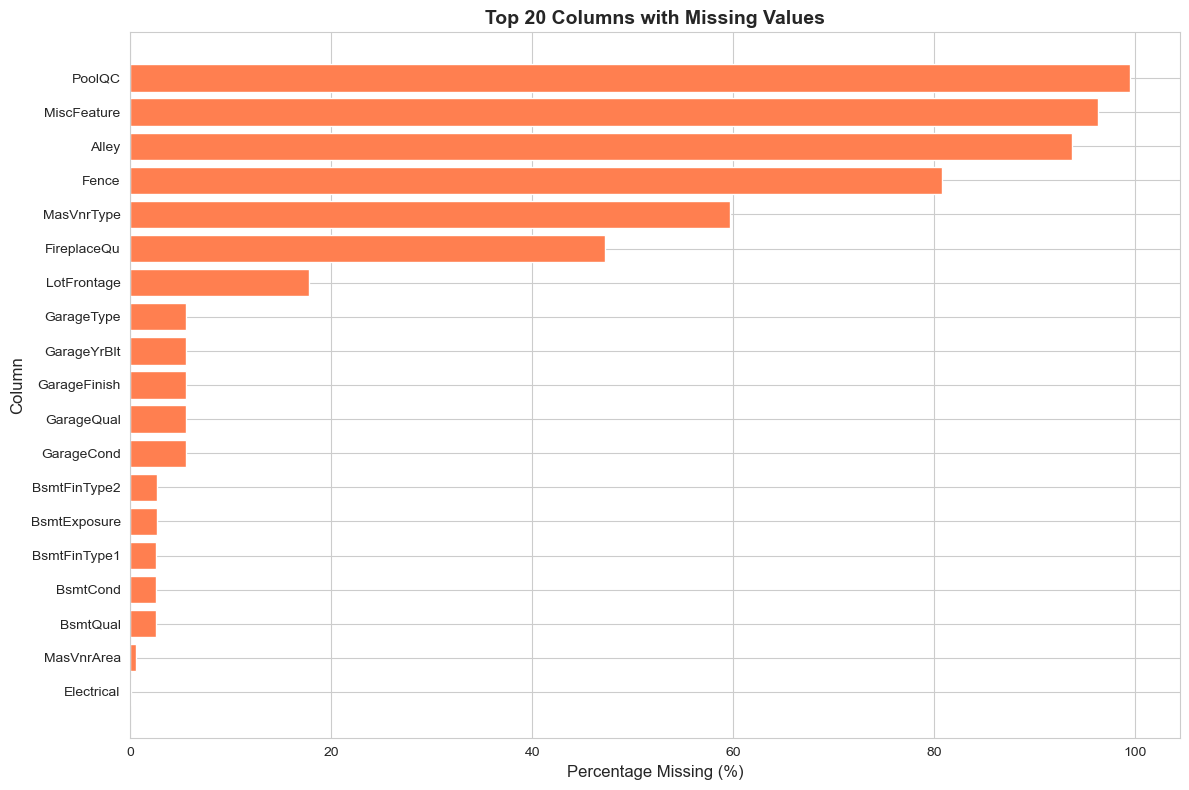


✓ Saved: visuals/01_missing_values.png


In [5]:
print("="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)

# Calculate missing values
missing = train.isnull().sum()
missing_pct = (missing / len(train)) * 100

# Create dataframe
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Percentage': missing_pct.values
})

# Filter columns with missing values
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False)

print(f"\nColumns with missing values: {len(missing_df)}")
print("\n", missing_df.to_string(index=False))

# Visualize top 20 columns with most missing values
if len(missing_df) > 0:
    top_missing = missing_df.head(20)
    
    plt.figure(figsize=(12, 8))
    plt.barh(top_missing['Column'], top_missing['Percentage'], color='coral')
    plt.xlabel('Percentage Missing (%)', fontsize=12)
    plt.ylabel('Column', fontsize=12)
    plt.title('Top 20 Columns with Missing Values', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/01_missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Saved: visuals/01_missing_values.png")

TARGET VARIABLE DISTRIBUTION

SalePrice Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.88
  → Highly right-skewed (consider log transformation)


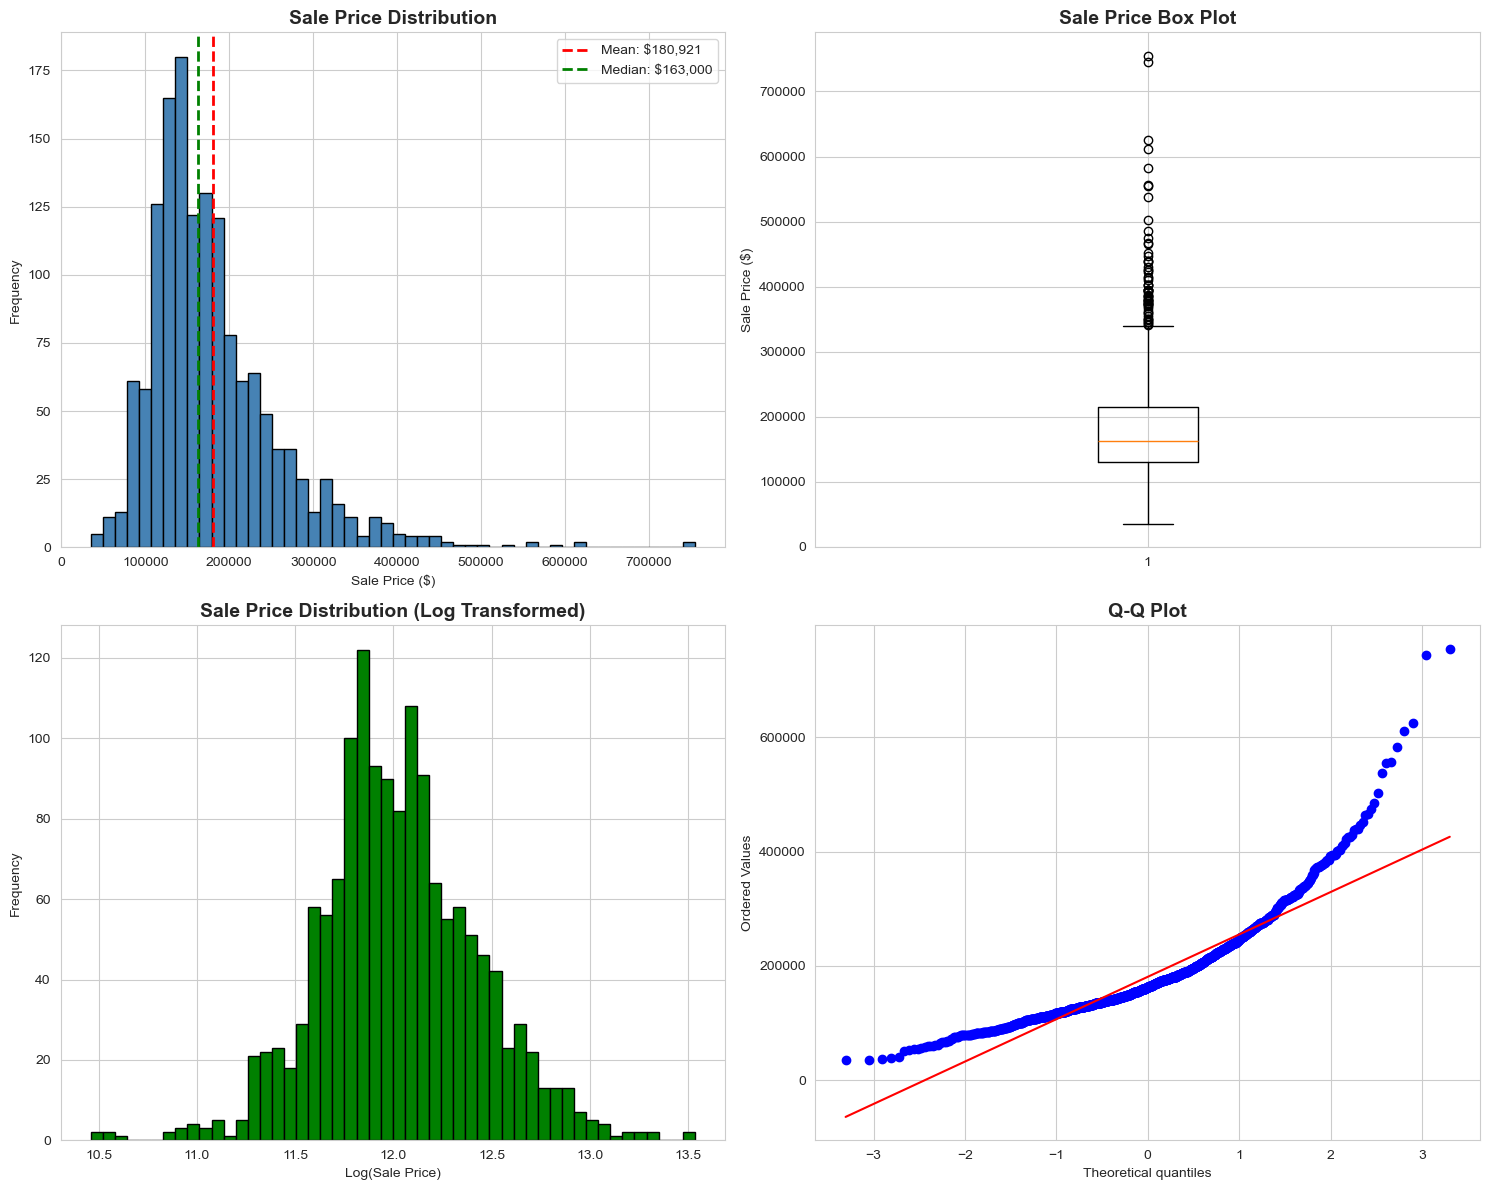


✓ Saved: visuals/02_target_distribution.png


In [6]:
print("="*60)
print("TARGET VARIABLE DISTRIBUTION")
print("="*60)

# Statistics
print(f"\nSalePrice Statistics:")
print(train['SalePrice'].describe())

# Check for skewness
sale_price_skew = train['SalePrice'].skew()
print(f"\nSkewness: {sale_price_skew:.2f}")
if sale_price_skew > 1:
    print("  → Highly right-skewed (consider log transformation)")
elif sale_price_skew > 0.5:
    print("  → Moderately right-skewed")
else:
    print("  → Fairly symmetric")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram
axes[0, 0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Sale Price Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Sale Price ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(train['SalePrice'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: ${train['SalePrice'].mean():,.0f}")
axes[0, 0].axvline(train['SalePrice'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f"Median: ${train['SalePrice'].median():,.0f}")
axes[0, 0].legend()

# Box plot
axes[0, 1].boxplot(train['SalePrice'], vert=True)
axes[0, 1].set_title('Sale Price Box Plot', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Sale Price ($)')

# Log-transformed histogram
log_price = np.log1p(train['SalePrice'])
axes[1, 0].hist(log_price, bins=50, color='green', edgecolor='black')
axes[1, 0].set_title('Sale Price Distribution (Log Transformed)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Log(Sale Price)')
axes[1, 0].set_ylabel('Frequency')

# Q-Q plot
stats.probplot(train['SalePrice'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/02_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/02_target_distribution.png")

In [7]:
print("="*60)
print("FEATURE TYPES")
print("="*60)

# Identify numerical and categorical columns
numerical_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train.select_dtypes(include=['object']).columns.tolist()

# Remove ID and target from numerical
if 'Id' in numerical_features:
    numerical_features.remove('Id')
if 'SalePrice' in numerical_features:
    numerical_features.remove('SalePrice')

print(f"\nNumerical Features: {len(numerical_features)}")
print(f"  Examples: {numerical_features[:5]}")

print(f"\nCategorical Features: {len(categorical_features)}")
print(f"  Examples: {categorical_features[:5]}")

# Save feature lists
with open('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/reports/01_feature_types.txt', 'w') as f:
    f.write("NUMERICAL FEATURES:\n")
    f.write("\n".join(numerical_features))
    f.write("\n\nCATEGORICAL FEATURES:\n")
    f.write("\n".join(categorical_features))

print("\n✓ Saved: reports/01_feature_types.txt")

FEATURE TYPES

Numerical Features: 36
  Examples: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond']

Categorical Features: 43
  Examples: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour']

✓ Saved: reports/01_feature_types.txt


CORRELATION ANALYSIS

Top 15 Features Most Correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


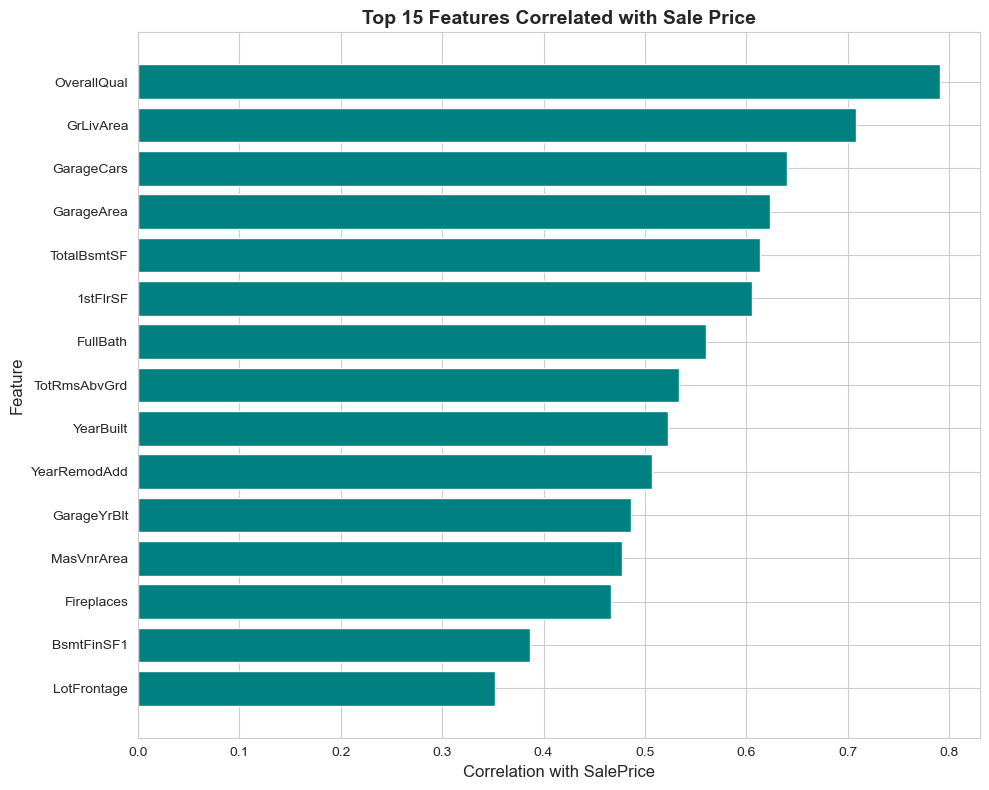


✓ Saved: visuals/03_top_correlations.png


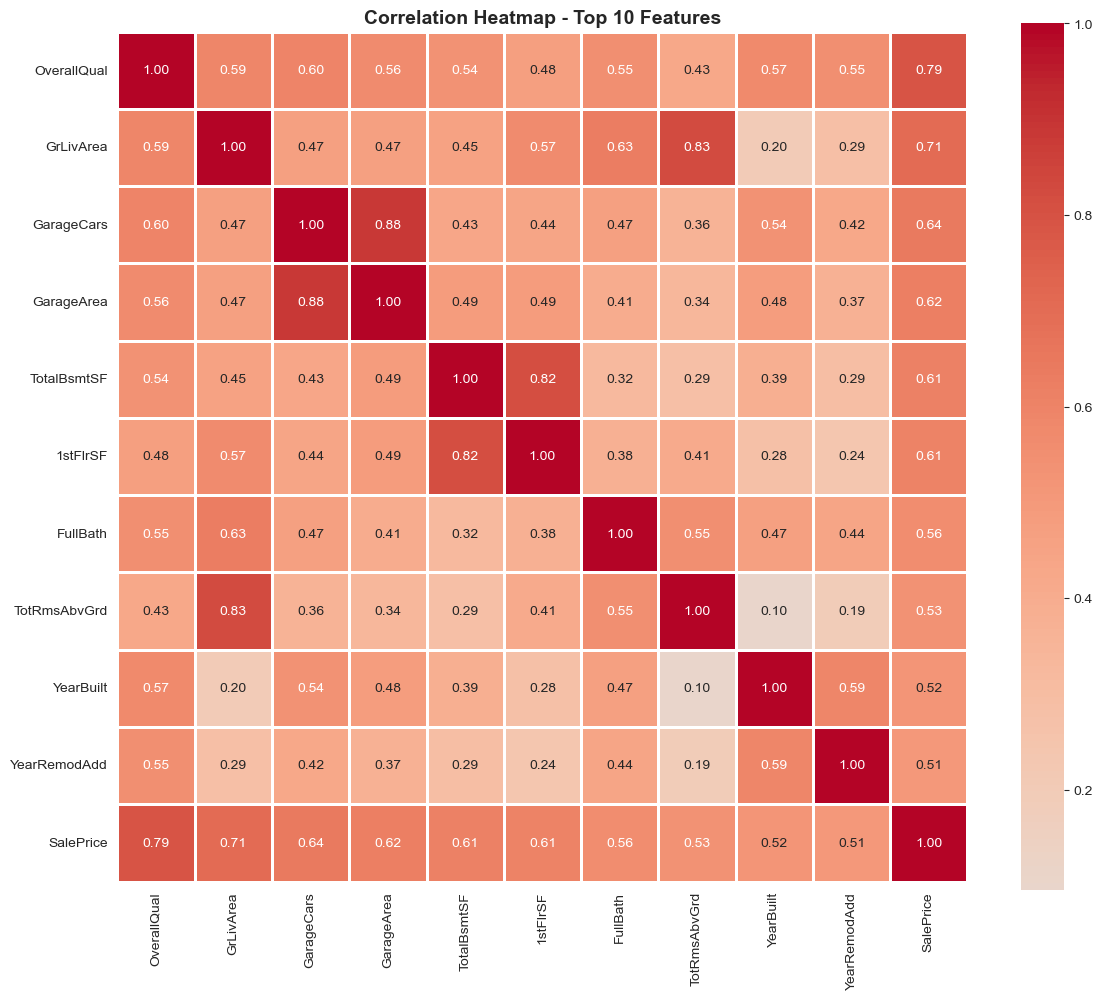

✓ Saved: visuals/04_correlation_heatmap.png


In [8]:
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Calculate correlations with SalePrice
correlations = train[numerical_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
correlations = correlations.sort_values(ascending=False)

print("\nTop 15 Features Most Correlated with SalePrice:")
print(correlations.head(15))

# Visualize top correlations
top_corr = correlations.head(15)

plt.figure(figsize=(10, 8))
plt.barh(top_corr.index, top_corr.values, color='teal')
plt.xlabel('Correlation with SalePrice', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Features Correlated with Sale Price', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/03_top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/03_top_correlations.png")

# Correlation heatmap (top features)
top_features = correlations.head(10).index.tolist() + ['SalePrice']
corr_matrix = train[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap - Top 10 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: visuals/04_correlation_heatmap.png")

In [9]:
print("="*60)
print("INITIAL EXPLORATION - KEY FINDINGS")
print("="*60)

insights = f"""
HOUSE PRICE PREDICTION - DATA UNDERSTANDING

DATASET OVERVIEW:
- Total houses: {len(train):,}
- Total features: {train.shape[1] - 1} (excluding SalePrice)
- Numerical features: {len(numerical_features)}
- Categorical features: {len(categorical_features)}

TARGET VARIABLE (SalePrice):
- Mean: ${train['SalePrice'].mean():,.2f}
- Median: ${train['SalePrice'].median():,.2f}
- Range: ${train['SalePrice'].min():,.2f} - ${train['SalePrice'].max():,.2f}
- Skewness: {train['SalePrice'].skew():.2f} (right-skewed)
- Recommendation: Apply log transformation

MISSING VALUES:
- Columns with missing values: {len(missing_df)}
- Most missing: {missing_df.iloc[0]['Column']} ({missing_df.iloc[0]['Percentage']:.1f}%)

TOP 5 CORRELATED FEATURES WITH SALEPRICE:
1. {correlations.index[0]}: {correlations.iloc[0]:.3f}
2. {correlations.index[1]}: {correlations.iloc[1]:.3f}
3. {correlations.index[2]}: {correlations.iloc[2]:.3f}
4. {correlations.index[3]}: {correlations.iloc[3]:.3f}
5. {correlations.index[4]}: {correlations.iloc[4]:.3f}

NEXT STEPS:
1. Handle missing values
2. Detect and handle outliers
3. Feature engineering
4. Apply transformations (log, scaling)
5. Encode categorical variables
6. Build regression models
"""

print(insights)

# Save insights
with open('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/reports/02_initial_insights.txt', 'w') as f:
    f.write(insights)

print("\n✓ Saved: reports/02_initial_insights.txt")

INITIAL EXPLORATION - KEY FINDINGS

HOUSE PRICE PREDICTION - DATA UNDERSTANDING

DATASET OVERVIEW:
- Total houses: 1,460
- Total features: 80 (excluding SalePrice)
- Numerical features: 36
- Categorical features: 43

TARGET VARIABLE (SalePrice):
- Mean: $180,921.20
- Median: $163,000.00
- Range: $34,900.00 - $755,000.00
- Skewness: 1.88 (right-skewed)
- Recommendation: Apply log transformation

MISSING VALUES:
- Columns with missing values: 19
- Most missing: PoolQC (99.5%)

TOP 5 CORRELATED FEATURES WITH SALEPRICE:
1. OverallQual: 0.791
2. GrLivArea: 0.709
3. GarageCars: 0.640
4. GarageArea: 0.623
5. TotalBsmtSF: 0.614

NEXT STEPS:
1. Handle missing values
2. Detect and handle outliers
3. Feature engineering
4. Apply transformations (log, scaling)
5. Encode categorical variables
6. Build regression models


✓ Saved: reports/02_initial_insights.txt


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("DATA CLEANING & FEATURE ENGINEERING")
print("="*60)

# Load data
train = pd.read_csv('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/data/raw/train.csv')
print(f"\nOriginal dataset: {train.shape}")

# Make a copy
df = train.copy()

DATA CLEANING & FEATURE ENGINEERING

Original dataset: (1460, 81)


In [11]:
print("\n" + "="*60)
print("STEP 1: HANDLE MISSING VALUES")
print("="*60)

# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing': missing.values,
    'Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False)

print(f"\nColumns with missing values: {len(missing_df)}")

# Strategy for handling missing values

# 1. Features where NA means "None" (no such feature)
none_features = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
                'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 
                'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

for col in none_features:
    if col in df.columns:
        df[col].fillna('None', inplace=True)
        print(f"  ✓ {col}: Filled NA with 'None'")

# 2. Numerical features where NA means 0
zero_features = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 
                'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 
                'BsmtHalfBath', 'MasVnrArea']

for col in zero_features:
    if col in df.columns:
        df[col].fillna(0, inplace=True)
        print(f"  ✓ {col}: Filled NA with 0")

# 3. Fill with mode (most common value) for remaining categorical
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"  ✓ {col}: Filled NA with mode '{mode_value}'")

# 4. Fill with median for remaining numerical
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"  ✓ {col}: Filled NA with median {median_value}")

print(f"\nMissing values after handling: {df.isnull().sum().sum()}")


STEP 1: HANDLE MISSING VALUES

Columns with missing values: 19
  ✓ Alley: Filled NA with 'None'
  ✓ BsmtQual: Filled NA with 'None'
  ✓ BsmtCond: Filled NA with 'None'
  ✓ BsmtExposure: Filled NA with 'None'
  ✓ BsmtFinType1: Filled NA with 'None'
  ✓ BsmtFinType2: Filled NA with 'None'
  ✓ FireplaceQu: Filled NA with 'None'
  ✓ GarageType: Filled NA with 'None'
  ✓ GarageFinish: Filled NA with 'None'
  ✓ GarageQual: Filled NA with 'None'
  ✓ GarageCond: Filled NA with 'None'
  ✓ PoolQC: Filled NA with 'None'
  ✓ Fence: Filled NA with 'None'
  ✓ MiscFeature: Filled NA with 'None'
  ✓ GarageYrBlt: Filled NA with 0
  ✓ GarageArea: Filled NA with 0
  ✓ GarageCars: Filled NA with 0
  ✓ BsmtFinSF1: Filled NA with 0
  ✓ BsmtFinSF2: Filled NA with 0
  ✓ BsmtUnfSF: Filled NA with 0
  ✓ TotalBsmtSF: Filled NA with 0
  ✓ BsmtFullBath: Filled NA with 0
  ✓ BsmtHalfBath: Filled NA with 0
  ✓ MasVnrArea: Filled NA with 0
  ✓ MasVnrType: Filled NA with mode 'BrkFace'
  ✓ Electrical: Filled NA with 


STEP 2: OUTLIER DETECTION

Outliers in key numerical features:
  GrLivArea: 31 outliers (bounds: 159 - 2748)
  TotalBsmtSF: 61 outliers (bounds: 42 - 2052)
  LotArea: 69 outliers (bounds: 1482 - 17674)
  1stFlrSF: 20 outliers (bounds: 118 - 2155)
  GarageArea: 21 outliers (bounds: -28 - 938)


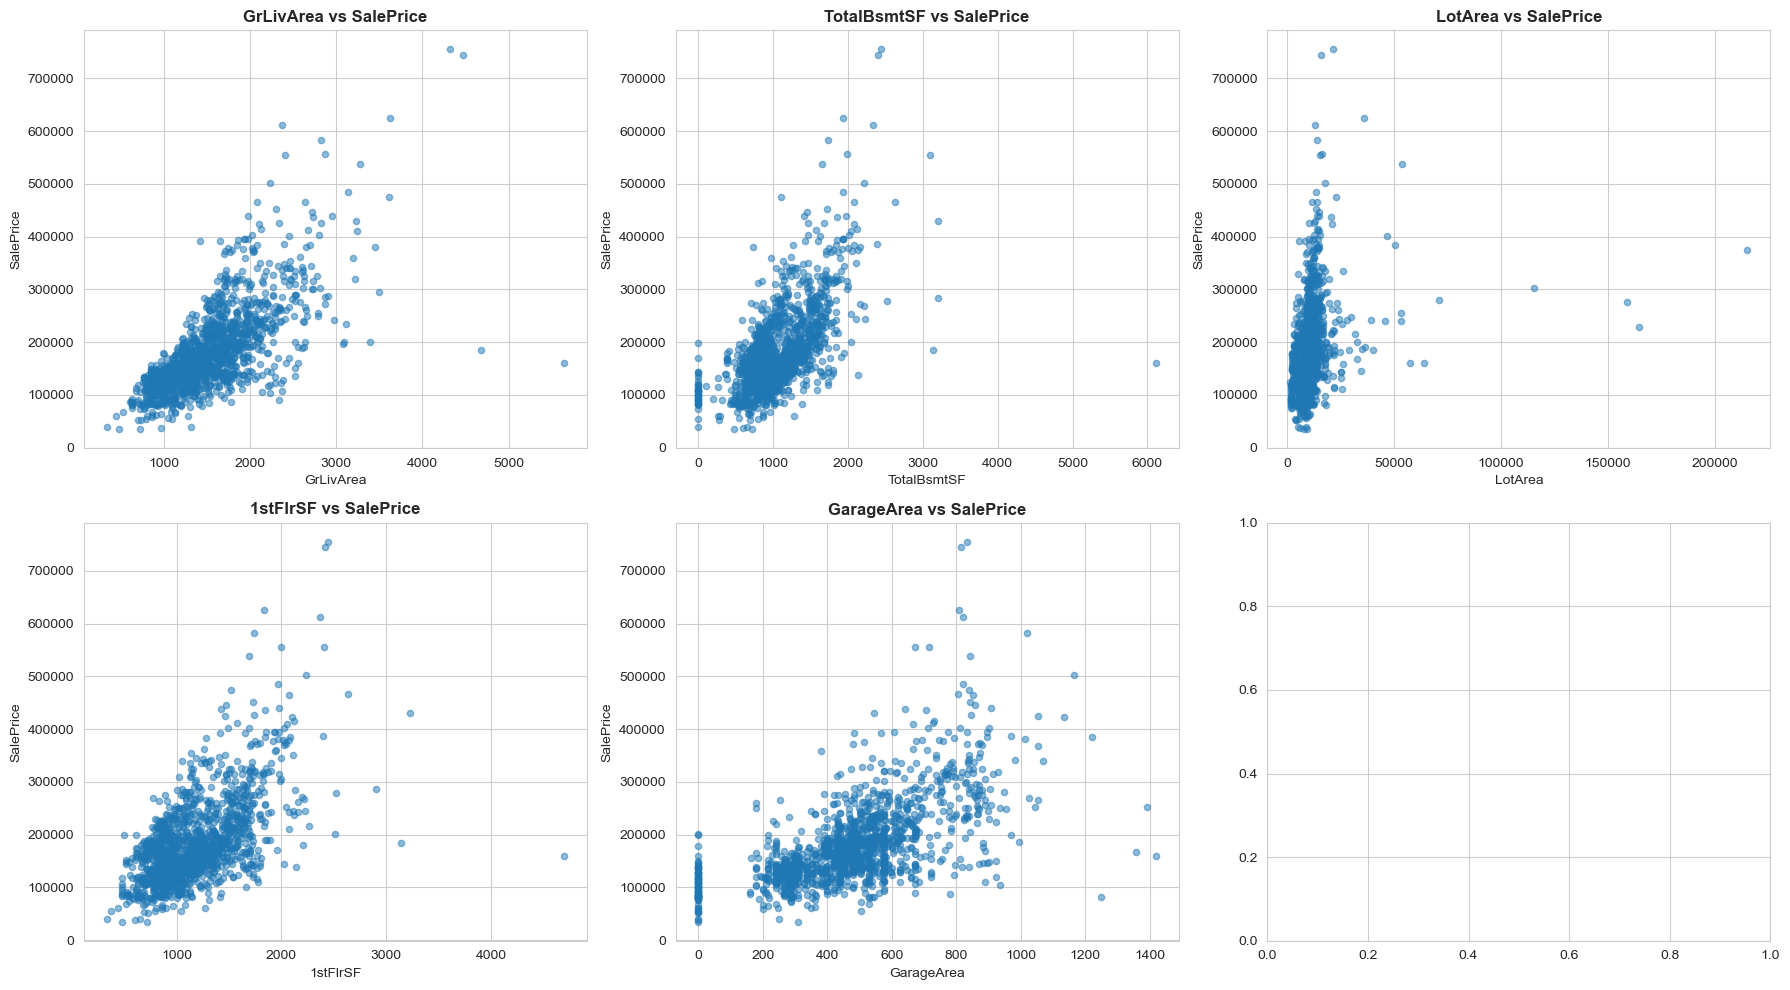


✓ Saved: visuals/05_outlier_analysis.png

Removing extreme outliers...
  Before: 1460 rows
  After: 1458 rows
  Removed: 2 outliers


In [13]:
print("\n" + "="*60)
print("STEP 2: OUTLIER DETECTION")
print("="*60)

# Identify outliers in key numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Id' in numerical_features:
    numerical_features.remove('Id')
if 'SalePrice' in numerical_features:
    numerical_features.remove('SalePrice')

# Function to detect outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Check outliers in key features
print("\nOutliers in key numerical features:")
key_features = ['GrLivArea', 'TotalBsmtSF', 'LotArea', '1stFlrSF', 'GarageArea']

for feature in key_features:
    if feature in df.columns:
        n_outliers, lower, upper = detect_outliers_iqr(df, feature)
        print(f"  {feature}: {n_outliers} outliers (bounds: {lower:.0f} - {upper:.0f})")

# Visualize relationship with SalePrice
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features[:6]):
    if feature in df.columns:
        axes[idx].scatter(df[feature], df['SalePrice'], alpha=0.5, s=20)
        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].set_ylabel('SalePrice', fontsize=10)
        axes[idx].set_title(f'{feature} vs SalePrice', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/05_outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/05_outlier_analysis.png")

# Remove extreme outliers in GrLivArea (houses with >4000 sqft but low price)
print("\nRemoving extreme outliers...")
print(f"  Before: {len(df)} rows")
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))]
print(f"  After: {len(df)} rows")
print(f"  Removed: {len(train) - len(df)} outliers")

In [14]:
print("\n" + "="*60)
print("STEP 3: FEATURE ENGINEERING")
print("="*60)

# 1. Total Square Footage
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
print("✓ Created TotalSF (total square footage)")

# 2. Total Bathrooms
df['TotalBath'] = (df['FullBath'] + (0.5 * df['HalfBath']) + 
                   df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))
print("✓ Created TotalBath (total bathrooms)")

# 3. Age of house
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
print("✓ Created HouseAge and RemodAge")

# 4. Has features (binary flags)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
print("✓ Created binary feature flags (HasPool, Has2ndFloor, etc.)")

# 5. Quality scores
df['OverallScore'] = df['OverallQual'] * df['OverallCond']
print("✓ Created OverallScore")

# 6. Porch area
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + 
                      df['3SsnPorch'] + df['ScreenPorch'])
print("✓ Created TotalPorchSF")

print(f"\nTotal features after engineering: {df.shape[1]}")


STEP 3: FEATURE ENGINEERING
✓ Created TotalSF (total square footage)
✓ Created TotalBath (total bathrooms)
✓ Created HouseAge and RemodAge
✓ Created binary feature flags (HasPool, Has2ndFloor, etc.)
✓ Created OverallScore
✓ Created TotalPorchSF

Total features after engineering: 92



STEP 4: TARGET TRANSFORMATION
Original SalePrice skewness: 1.88
Log-transformed skewness: 0.12


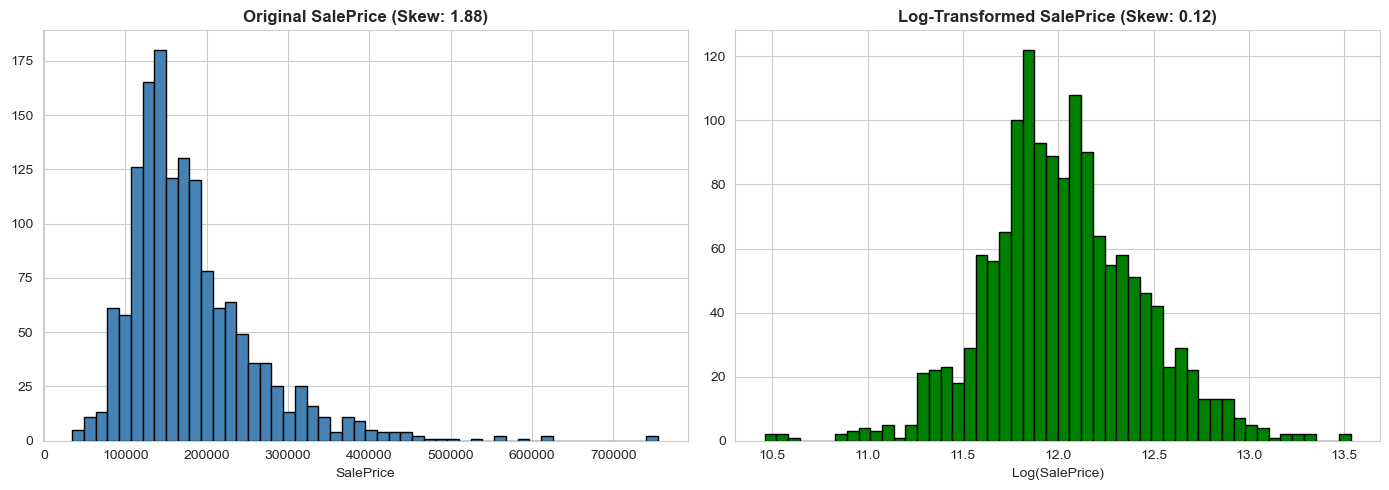


✓ Saved: visuals/06_target_transformation.png
✓ Target variable normalized


In [15]:
print("\n" + "="*60)
print("STEP 4: TARGET TRANSFORMATION")
print("="*60)

# Apply log transformation to SalePrice
df['SalePrice_Log'] = np.log1p(df['SalePrice'])

print(f"Original SalePrice skewness: {df['SalePrice'].skew():.2f}")
print(f"Log-transformed skewness: {df['SalePrice_Log'].skew():.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title(f'Original SalePrice (Skew: {df["SalePrice"].skew():.2f})', 
                 fontsize=12, fontweight='bold')
axes[0].set_xlabel('SalePrice')

axes[1].hist(df['SalePrice_Log'], bins=50, color='green', edgecolor='black')
axes[1].set_title(f'Log-Transformed SalePrice (Skew: {df["SalePrice_Log"].skew():.2f})', 
                 fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log(SalePrice)')

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/06_target_transformation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/06_target_transformation.png")
print("✓ Target variable normalized")

In [16]:
print("\n" + "="*60)
print("STEP 5: TRANSFORM SKEWED FEATURES")
print("="*60)

# Get numerical features (excluding target)
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
remove_cols = ['Id', 'SalePrice', 'SalePrice_Log']
for col in remove_cols:
    if col in numerical_features:
        numerical_features.remove(col)

# Calculate skewness
skewed_features = []
for feature in numerical_features:
    skewness = df[feature].skew()
    if abs(skewness) > 0.75:  # Threshold for skewness
        skewed_features.append((feature, skewness))

skewed_features = sorted(skewed_features, key=lambda x: abs(x[1]), reverse=True)

print(f"\nHighly skewed features (|skew| > 0.75): {len(skewed_features)}")
print("\nTop 10 most skewed:")
for feature, skewness in skewed_features[:10]:
    print(f"  {feature}: {skewness:.2f}")

# Apply log transformation to skewed features
print("\nApplying log transformation to skewed features...")
for feature, skewness in skewed_features:
    if feature in df.columns:
        df[feature] = np.log1p(df[feature])

print(f"✓ Transformed {len(skewed_features)} skewed features")


STEP 5: TRANSFORM SKEWED FEATURES

Highly skewed features (|skew| > 0.75): 26

Top 10 most skewed:
  MiscVal: 24.46
  PoolArea: 15.95
  HasPool: 15.51
  LotArea: 12.57
  3SsnPorch: 10.30
  LowQualFinSF: 9.00
  HasBsmt: -6.04
  KitchenAbvGr: 4.48
  BsmtFinSF2: 4.25
  ScreenPorch: 4.12

Applying log transformation to skewed features...
✓ Transformed 26 skewed features


In [17]:
print("\n" + "="*60)
print("STEP 6: ENCODE CATEGORICAL VARIABLES")
print("="*60)

# Get categorical columns
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nCategorical features to encode: {len(categorical_features)}")

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print(f"\nShape after encoding:")
print(f"  Before: {df.shape}")
print(f"  After: {df_encoded.shape}")
print(f"  New features created: {df_encoded.shape[1] - df.shape[1]}")

print("\n✓ Categorical variables encoded")


STEP 6: ENCODE CATEGORICAL VARIABLES

Categorical features to encode: 43

Shape after encoding:
  Before: (1458, 93)
  After: (1458, 271)
  New features created: 178

✓ Categorical variables encoded


In [19]:
print("\n" + "="*60)
print("STEP 7: SAVE PROCESSED DATA")
print("="*60)

# Save processed dataset
df_encoded.to_csv('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/data/processed/housing_processed.csv', index=False)
print("✓ Saved: data/processed/housing_processed.csv")

# Save feature names
feature_cols = [col for col in df_encoded.columns if col not in ['Id', 'SalePrice', 'SalePrice_Log']]
with open('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/data/processed/feature_names.txt', 'w') as f:
    for feature in feature_cols:
        f.write(f"{feature}\n")
print("✓ Saved: data/processed/feature_names.txt")

# Summary
summary = f"""
DATA CLEANING & FEATURE ENGINEERING - SUMMARY

CLEANING STEPS:
1. Handled missing values in {len(missing_df)} columns
2. Removed {len(train) - len(df)} extreme outliers
3. Transformed {len(skewed_features)} skewed features

FEATURE ENGINEERING:
- Created 10+ new features (TotalSF, TotalBath, HouseAge, etc.)
- Applied log transformation to target (SalePrice)
- One-hot encoded {len(categorical_features)} categorical variables

FINAL DATASET:
- Original features: {train.shape[1]}
- After engineering: {df.shape[1]}
- After encoding: {df_encoded.shape[1]}
- Total features for modeling: {len(feature_cols)}

NEW FEATURES CREATED:
- TotalSF (total square footage)
- TotalBath (total bathrooms)
- HouseAge, RemodAge
- HasPool, Has2ndFloor, HasGarage, HasBsmt, HasFireplace
- OverallScore
- TotalPorchSF

READY FOR MODELING: YES ✓
"""

print(summary)

# Save summary
with open('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/reports/03_preprocessing_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✓ Saved: reports/03_preprocessing_summary.txt")


STEP 7: SAVE PROCESSED DATA
✓ Saved: data/processed/housing_processed.csv
✓ Saved: data/processed/feature_names.txt

DATA CLEANING & FEATURE ENGINEERING - SUMMARY

CLEANING STEPS:
1. Handled missing values in 19 columns
2. Removed 2 extreme outliers
3. Transformed 26 skewed features

FEATURE ENGINEERING:
- Created 10+ new features (TotalSF, TotalBath, HouseAge, etc.)
- Applied log transformation to target (SalePrice)
- One-hot encoded 43 categorical variables

FINAL DATASET:
- Original features: 81
- After engineering: 93
- After encoding: 271
- Total features for modeling: 268

NEW FEATURES CREATED:
- TotalSF (total square footage)
- TotalBath (total bathrooms)
- HouseAge, RemodAge
- HasPool, Has2ndFloor, HasGarage, HasBsmt, HasFireplace
- OverallScore
- TotalPorchSF

READY FOR MODELING: YES ✓


✓ Saved: reports/03_preprocessing_summary.txt


In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("MODEL BUILDING & EVALUATION")
print("="*60)

# Load processed data
df = pd.read_csv('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/data/processed/housing_processed.csv')

print(f"\nData loaded: {df.shape}")

MODEL BUILDING & EVALUATION

Data loaded: (1458, 271)


In [21]:
print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)

# Separate features and target
# We'll use log-transformed target
X = df.drop(['Id', 'SalePrice', 'SalePrice_Log'], axis=1, errors='ignore')
y = df['SalePrice_Log']  # Using log-transformed target

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain-Test Split:")
print(f"  Training: {X_train.shape[0]} samples")
print(f"  Testing: {X_test.shape[0]} samples")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features scaled using StandardScaler")

# Save scaler
with open('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved: models/scaler.pkl")


DATA PREPARATION

Features shape: (1458, 268)
Target shape: (1458,)
Number of features: 268

Train-Test Split:
  Training: 1166 samples
  Testing: 292 samples

✓ Features scaled using StandardScaler
✓ Scaler saved: models/scaler.pkl


In [22]:
print("\n" + "="*60)
print("HELPER FUNCTIONS")
print("="*60)

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Train and evaluate a regression model
    Returns metrics dict
    """
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics (on log scale)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Also calculate on original scale (inverse log transform)
    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)
    y_train_pred_orig = np.expm1(y_train_pred)
    y_test_pred_orig = np.expm1(y_test_pred)
    
    test_rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
    test_mae_orig = mean_absolute_error(y_test_orig, y_test_pred_orig)
    
    metrics = {
        'Model': model_name,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Test_RMSE_Original': test_rmse_orig,
        'Test_MAE_Original': test_mae_orig
    }
    
    return metrics, model

print("✓ Helper functions defined")


HELPER FUNCTIONS
✓ Helper functions defined


In [23]:
print("\n" + "="*60)
print("MODEL 1: LINEAR REGRESSION (Baseline)")
print("="*60)

lr_model = LinearRegression()
lr_metrics, lr_model = evaluate_model(
    lr_model, X_train_scaled, y_train, X_test_scaled, y_test, 
    'Linear Regression'
)

print("\nPerformance Metrics:")
print(f"  Train RMSE (log): {lr_metrics['Train_RMSE']:.4f}")
print(f"  Test RMSE (log):  {lr_metrics['Test_RMSE']:.4f}")
print(f"  Test RMSE ($):    ${lr_metrics['Test_RMSE_Original']:,.2f}")
print(f"  Test MAE ($):     ${lr_metrics['Test_MAE_Original']:,.2f}")
print(f"  Train R²:         {lr_metrics['Train_R2']:.4f}")
print(f"  Test R²:          {lr_metrics['Test_R2']:.4f}")

print("\n✓ Linear Regression trained")


MODEL 1: LINEAR REGRESSION (Baseline)

Performance Metrics:
  Train RMSE (log): 0.0851
  Test RMSE (log):  0.1377
  Test RMSE ($):    $21,289.53
  Test MAE ($):     $14,761.93
  Train R²:         0.9540
  Test R²:          0.8876

✓ Linear Regression trained


In [24]:
print("\n" + "="*60)
print("MODEL 2: RIDGE REGRESSION")
print("="*60)

ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_metrics, ridge_model = evaluate_model(
    ridge_model, X_train_scaled, y_train, X_test_scaled, y_test, 
    'Ridge Regression'
)

print("\nPerformance Metrics:")
print(f"  Train RMSE (log): {ridge_metrics['Train_RMSE']:.4f}")
print(f"  Test RMSE (log):  {ridge_metrics['Test_RMSE']:.4f}")
print(f"  Test RMSE ($):    ${ridge_metrics['Test_RMSE_Original']:,.2f}")
print(f"  Test MAE ($):     ${ridge_metrics['Test_MAE_Original']:,.2f}")
print(f"  Train R²:         {ridge_metrics['Train_R2']:.4f}")
print(f"  Test R²:          {ridge_metrics['Test_R2']:.4f}")

print("\n✓ Ridge Regression trained")


MODEL 2: RIDGE REGRESSION

Performance Metrics:
  Train RMSE (log): 0.0875
  Test RMSE (log):  0.1251
  Test RMSE ($):    $20,935.32
  Test MAE ($):     $14,650.81
  Train R²:         0.9514
  Test R²:          0.9071

✓ Ridge Regression trained


In [25]:
print("\n" + "="*60)
print("MODEL 3: LASSO REGRESSION")
print("="*60)

lasso_model = Lasso(alpha=0.0005, random_state=42, max_iter=10000)
lasso_metrics, lasso_model = evaluate_model(
    lasso_model, X_train_scaled, y_train, X_test_scaled, y_test, 
    'Lasso Regression'
)

print("\nPerformance Metrics:")
print(f"  Train RMSE (log): {lasso_metrics['Train_RMSE']:.4f}")
print(f"  Test RMSE (log):  {lasso_metrics['Test_RMSE']:.4f}")
print(f"  Test RMSE ($):    ${lasso_metrics['Test_RMSE_Original']:,.2f}")
print(f"  Test MAE ($):     ${lasso_metrics['Test_MAE_Original']:,.2f}")
print(f"  Train R²:         {lasso_metrics['Train_R2']:.4f}")
print(f"  Test R²:          {lasso_metrics['Test_R2']:.4f}")

print("\n✓ Lasso Regression trained")


MODEL 3: LASSO REGRESSION

Performance Metrics:
  Train RMSE (log): 0.0890
  Test RMSE (log):  0.1215
  Test RMSE ($):    $20,539.03
  Test MAE ($):     $14,390.46
  Train R²:         0.9497
  Test R²:          0.9124

✓ Lasso Regression trained


In [26]:
print("\n" + "="*60)
print("MODEL 4: ELASTICNET")
print("="*60)

elastic_model = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=10000)
elastic_metrics, elastic_model = evaluate_model(
    elastic_model, X_train_scaled, y_train, X_test_scaled, y_test, 
    'ElasticNet'
)

print("\nPerformance Metrics:")
print(f"  Train RMSE (log): {elastic_metrics['Train_RMSE']:.4f}")
print(f"  Test RMSE (log):  {elastic_metrics['Test_RMSE']:.4f}")
print(f"  Test RMSE ($):    ${elastic_metrics['Test_RMSE_Original']:,.2f}")
print(f"  Test MAE ($):     ${elastic_metrics['Test_MAE_Original']:,.2f}")
print(f"  Train R²:         {elastic_metrics['Train_R2']:.4f}")
print(f"  Test R²:          {elastic_metrics['Test_R2']:.4f}")

print("\n✓ ElasticNet trained")


MODEL 4: ELASTICNET

Performance Metrics:
  Train RMSE (log): 0.0891
  Test RMSE (log):  0.1215
  Test RMSE ($):    $20,527.15
  Test MAE ($):     $14,382.84
  Train R²:         0.9496
  Test R²:          0.9124

✓ ElasticNet trained


In [27]:
print("\n" + "="*60)
print("MODEL 5: RANDOM FOREST")
print("="*60)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_metrics, rf_model = evaluate_model(
    rf_model, X_train_scaled, y_train, X_test_scaled, y_test, 
    'Random Forest'
)

print("\nPerformance Metrics:")
print(f"  Train RMSE (log): {rf_metrics['Train_RMSE']:.4f}")
print(f"  Test RMSE (log):  {rf_metrics['Test_RMSE']:.4f}")
print(f"  Test RMSE ($):    ${rf_metrics['Test_RMSE_Original']:,.2f}")
print(f"  Test MAE ($):     ${rf_metrics['Test_MAE_Original']:,.2f}")
print(f"  Train R²:         {rf_metrics['Train_R2']:.4f}")
print(f"  Test R²:          {rf_metrics['Test_R2']:.4f}")

print("\n✓ Random Forest trained")


MODEL 5: RANDOM FOREST

Performance Metrics:
  Train RMSE (log): 0.0500
  Test RMSE (log):  0.1447
  Test RMSE ($):    $23,594.83
  Test MAE ($):     $16,491.33
  Train R²:         0.9841
  Test R²:          0.8758

✓ Random Forest trained


In [28]:
print("\n" + "="*60)
print("MODEL 6: GRADIENT BOOSTING")
print("="*60)

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, 
                                     max_depth=3, random_state=42)
gb_metrics, gb_model = evaluate_model(
    gb_model, X_train_scaled, y_train, X_test_scaled, y_test, 
    'Gradient Boosting'
)

print("\nPerformance Metrics:")
print(f"  Train RMSE (log): {gb_metrics['Train_RMSE']:.4f}")
print(f"  Test RMSE (log):  {gb_metrics['Test_RMSE']:.4f}")
print(f"  Test RMSE ($):    ${gb_metrics['Test_RMSE_Original']:,.2f}")
print(f"  Test MAE ($):     ${gb_metrics['Test_MAE_Original']:,.2f}")
print(f"  Train R²:         {gb_metrics['Train_R2']:.4f}")
print(f"  Test R²:          {gb_metrics['Test_R2']:.4f}")

print("\n✓ Gradient Boosting trained")


MODEL 6: GRADIENT BOOSTING

Performance Metrics:
  Train RMSE (log): 0.0753
  Test RMSE (log):  0.1292
  Test RMSE ($):    $21,132.18
  Test MAE ($):     $15,032.20
  Train R²:         0.9640
  Test R²:          0.9009

✓ Gradient Boosting trained


In [31]:
print("\n" + "="*60)
print("MODEL 7: XGBOOST")
print("="*60)

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, 
                        random_state=42)
xgb_metrics, xgb_model = evaluate_model(
    xgb_model, X_train_scaled, y_train, X_test_scaled, y_test, 
    'XGBoost'
)

print("\nPerformance Metrics:")
print(f"  Train RMSE (log): {xgb_metrics['Train_RMSE']:.4f}")
print(f"  Test RMSE (log):  {xgb_metrics['Test_RMSE']:.4f}")
print(f"  Test RMSE ($):    ${xgb_metrics['Test_RMSE_Original']:,.2f}")
print(f"  Test MAE ($):     ${xgb_metrics['Test_MAE_Original']:,.2f}")
print(f"  Train R²:         {xgb_metrics['Train_R2']:.4f}")
print(f"  Test R²:          {xgb_metrics['Test_R2']:.4f}")

print("\n✓ XGBoost trained")


MODEL 7: XGBOOST

Performance Metrics:
  Train RMSE (log): 0.0803
  Test RMSE (log):  0.1274
  Test RMSE ($):    $20,486.30
  Test MAE ($):     $14,582.44
  Train R²:         0.9590
  Test R²:          0.9037

✓ XGBoost trained



MODEL COMPARISON

             Model  Test_RMSE  Test_MAE  Test_R2
Linear Regression   0.137673  0.089241 0.887566
 Ridge Regression   0.125127  0.085538 0.907124
 Lasso Regression   0.121529  0.083636 0.912387
       ElasticNet   0.121519  0.083566 0.912402
    Random Forest   0.144693  0.097156 0.875806
Gradient Boosting   0.129240  0.088108 0.900917
          XGBoost   0.127424  0.086255 0.903682

✓ Saved: reports/model_comparison.csv


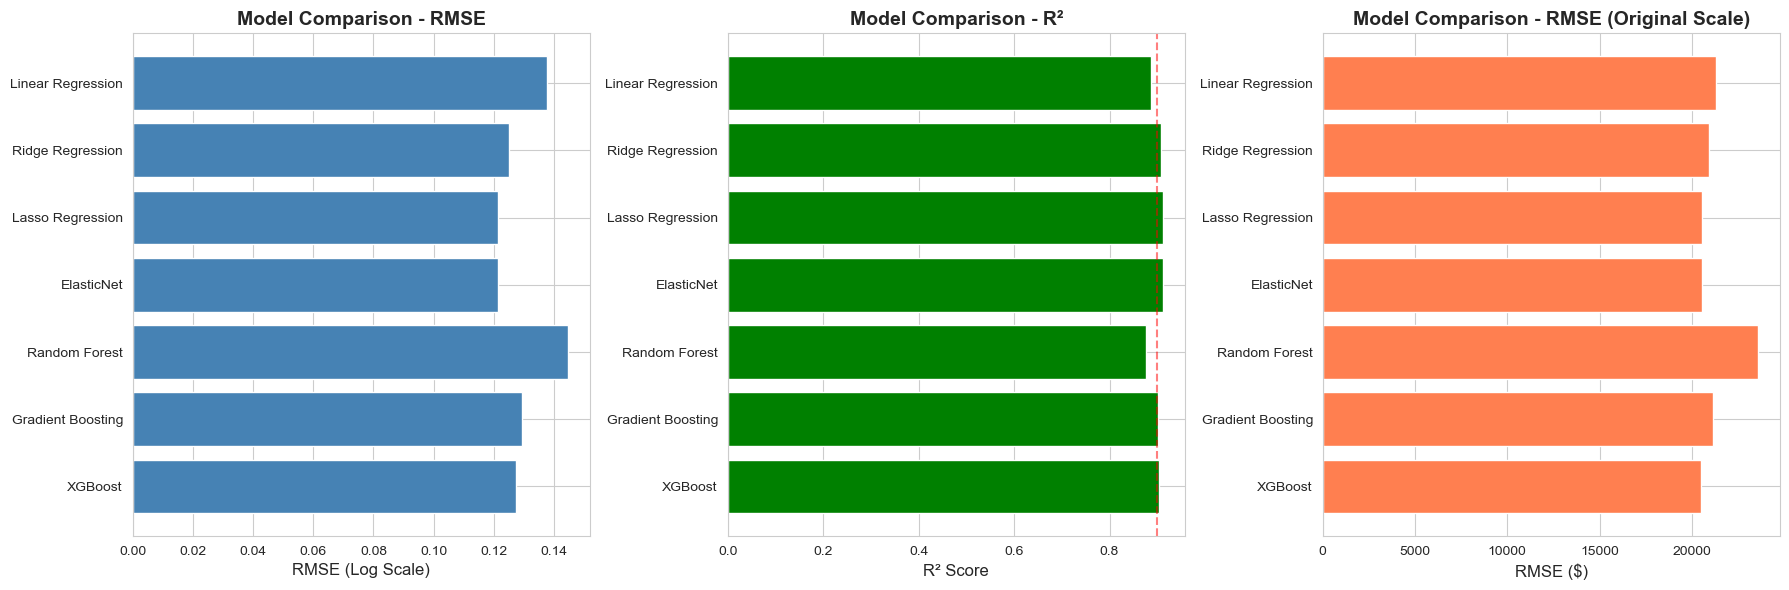

✓ Saved: visuals/07_model_comparison.png


In [30]:
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Compile all metrics
all_metrics = [lr_metrics, ridge_metrics, lasso_metrics, elastic_metrics,
               rf_metrics, gb_metrics, xgb_metrics]

comparison_df = pd.DataFrame(all_metrics)

# Display comparison
print("\n", comparison_df[['Model', 'Test_RMSE', 'Test_MAE', 'Test_R2']].to_string(index=False))

# Save comparison
comparison_df.to_csv('../reports/model_comparison.csv', index=False)
print("\n✓ Saved: reports/model_comparison.csv")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMSE Comparison
models = comparison_df['Model']
test_rmse = comparison_df['Test_RMSE']

axes[0].barh(models, test_rmse, color='steelblue')
axes[0].set_xlabel('RMSE (Log Scale)', fontsize=12)
axes[0].set_title('Model Comparison - RMSE', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# R² Comparison
test_r2 = comparison_df['Test_R2']
axes[1].barh(models, test_r2, color='green')
axes[1].set_xlabel('R² Score', fontsize=12)
axes[1].set_title('Model Comparison - R²', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].axvline(x=0.9, color='red', linestyle='--', alpha=0.5)

# RMSE in Dollars
test_rmse_orig = comparison_df['Test_RMSE_Original']
axes[2].barh(models, test_rmse_orig, color='coral')
axes[2].set_xlabel('RMSE ($)', fontsize=12)
axes[2].set_title('Model Comparison - RMSE (Original Scale)', fontsize=14, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/07_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: visuals/07_model_comparison.png")

In [32]:
print("\n" + "="*60)
print("BEST MODEL SELECTION")
print("="*60)

# Select based on lowest Test RMSE
best_idx = comparison_df['Test_RMSE'].idxmin()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_metrics = comparison_df.loc[best_idx]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Selected based on lowest Test RMSE")
print(f"\n   Performance:")
print(f"     Test RMSE (log): {best_metrics['Test_RMSE']:.4f}")
print(f"     Test RMSE ($):   ${best_metrics['Test_RMSE_Original']:,.2f}")
print(f"     Test MAE ($):    ${best_metrics['Test_MAE_Original']:,.2f}")
print(f"     Test R²:         {best_metrics['Test_R2']:.4f}")

# Save best model
if best_model_name == 'Linear Regression':
    best_model = lr_model
elif best_model_name == 'Ridge Regression':
    best_model = ridge_model
elif best_model_name == 'Lasso Regression':
    best_model = lasso_model
elif best_model_name == 'ElasticNet':
    best_model = elastic_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
elif best_model_name == 'Gradient Boosting':
    best_model = gb_model
else:
    best_model = xgb_model

with open('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"\n✓ Best model saved: models/best_model.pkl")


BEST MODEL SELECTION

🏆 BEST MODEL: ElasticNet
   Selected based on lowest Test RMSE

   Performance:
     Test RMSE (log): 0.1215
     Test RMSE ($):   $20,527.15
     Test MAE ($):    $14,382.84
     Test R²:         0.9124

✓ Best model saved: models/best_model.pkl



PREDICTION ANALYSIS


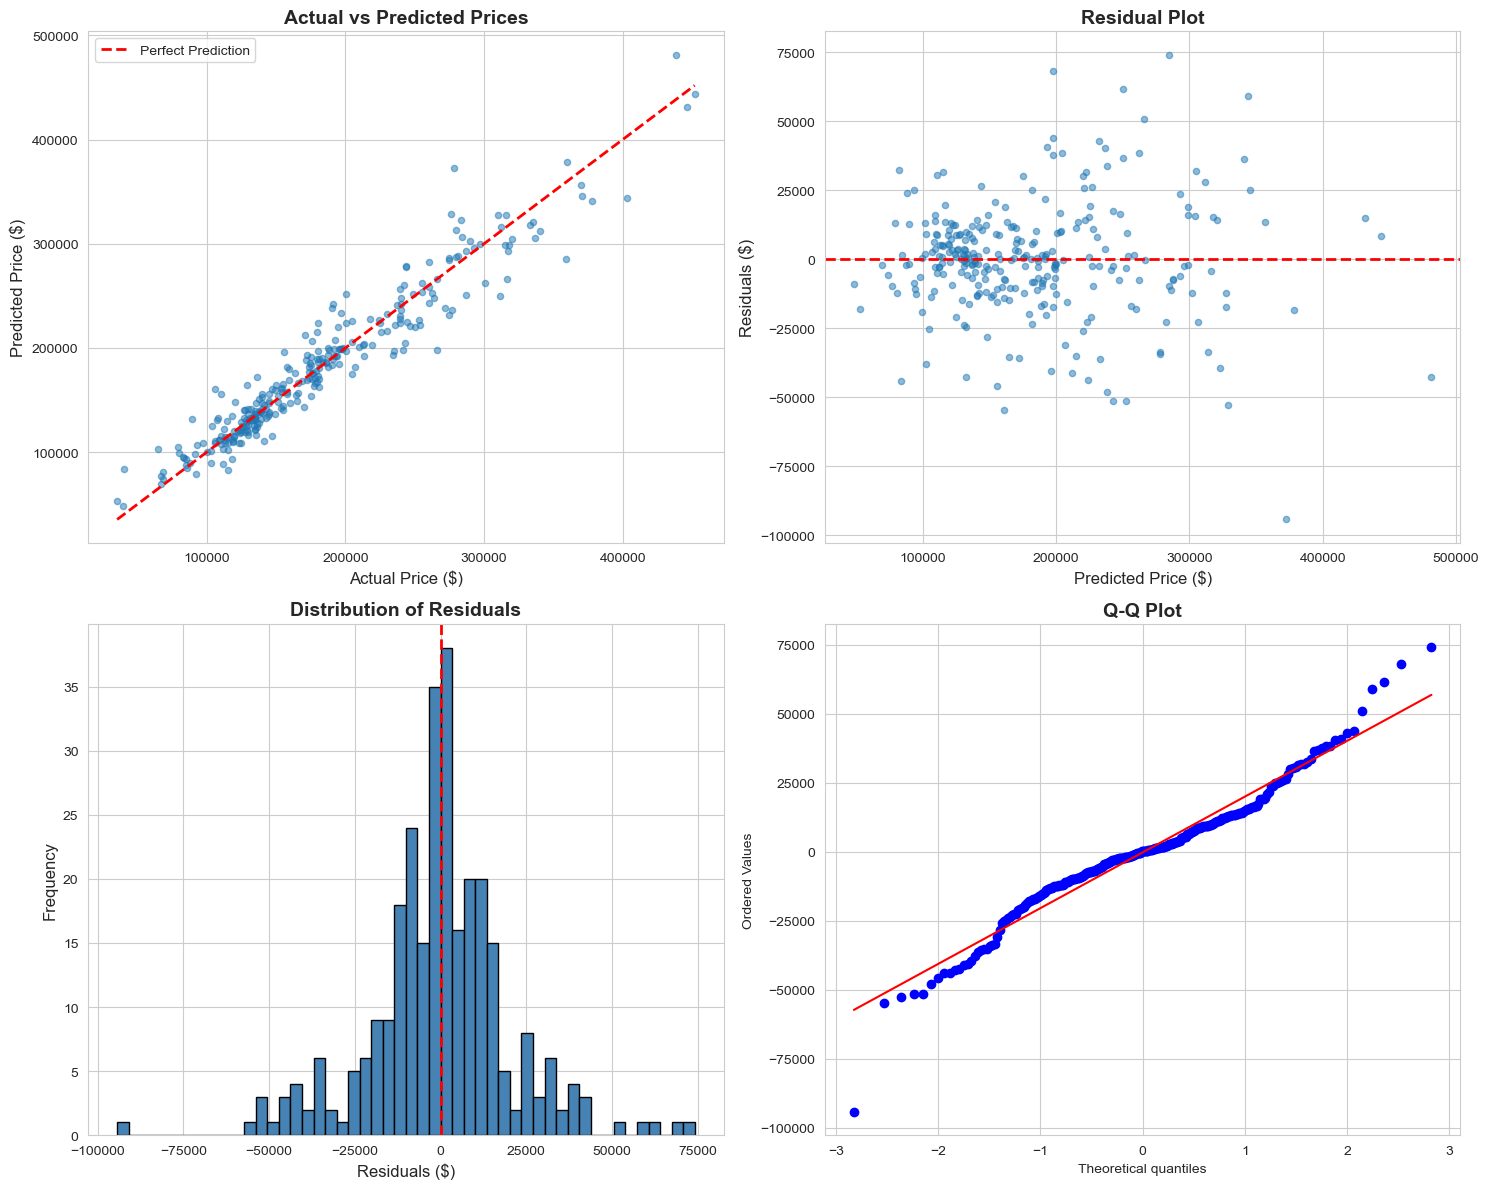

✓ Saved: visuals/08_prediction_analysis.png

Residual Statistics:
  Mean Error: $-268.05
  Median Error: $109.95
  Std Dev: $20,560.64
  Mean Absolute Error: $14,382.84


In [33]:
print("\n" + "="*60)
print("PREDICTION ANALYSIS")
print("="*60)

# Get predictions from best model
y_test_pred = best_model.predict(X_test_scaled)

# Convert back to original scale
y_test_orig = np.expm1(y_test)
y_test_pred_orig = np.expm1(y_test_pred)

# Calculate residuals
residuals = y_test_orig - y_test_pred_orig

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test_orig, y_test_pred_orig, alpha=0.5, s=20)
axes[0, 0].plot([y_test_orig.min(), y_test_orig.max()], 
                [y_test_orig.min(), y_test_orig.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0, 0].set_title('Actual vs Predicted Prices', fontsize=14, fontweight='bold')
axes[0, 0].legend()

# 2. Residual Plot
axes[0, 1].scatter(y_test_pred_orig, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[0, 1].set_ylabel('Residuals ($)', fontsize=12)
axes[0, 1].set_title('Residual Plot', fontsize=14, fontweight='bold')

# 3. Residual Distribution
axes[1, 0].hist(residuals, bins=50, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Residuals ($)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)

# 4. Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/08_prediction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: visuals/08_prediction_analysis.png")

# Error statistics
print(f"\nResidual Statistics:")
print(f"  Mean Error: ${residuals.mean():,.2f}")
print(f"  Median Error: ${residuals.median():,.2f}")
print(f"  Std Dev: ${residuals.std():,.2f}")
print(f"  Mean Absolute Error: ${np.abs(residuals).mean():,.2f}")


CROSS-VALIDATION

5-Fold Cross-Validation Results:
  Individual fold RMSE: [0.12856422 0.10260682 0.10981355 0.12153241 0.12573734]
  Mean RMSE: 0.1177
  Std Dev: 0.0099
  95% Confidence Interval: 0.1177 ± 0.0193


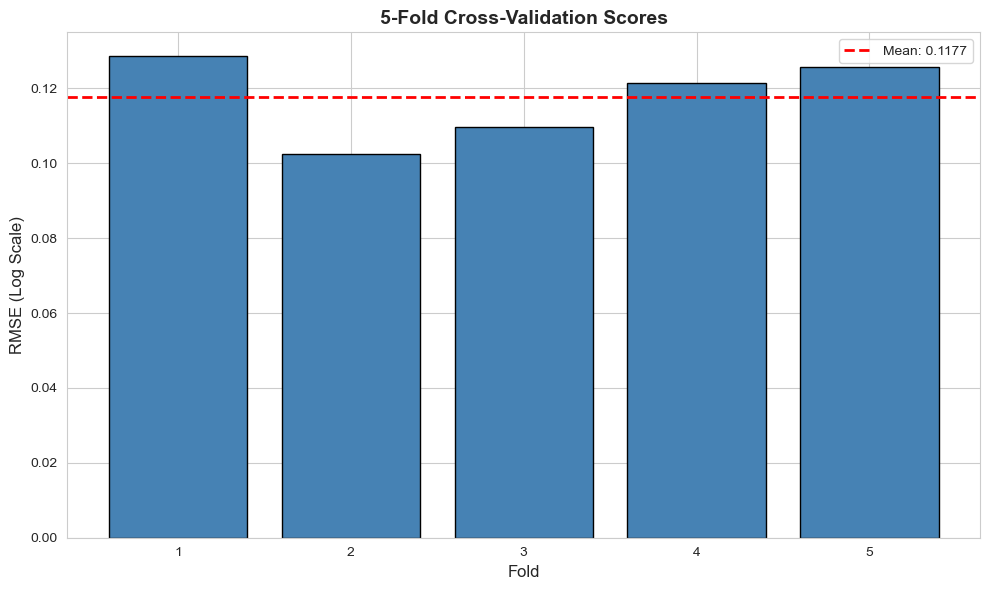


✓ Saved: visuals/09_cross_validation.png
✓ Model shows consistent performance across folds


In [34]:
print("\n" + "="*60)
print("CROSS-VALIDATION")
print("="*60)

# Perform 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculate RMSE for each fold (negative because sklearn uses negative MSE)
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, 
                            cv=kfold, scoring='neg_root_mean_squared_error')

# Convert to positive RMSE
cv_scores = -cv_scores

print(f"\n5-Fold Cross-Validation Results:")
print(f"  Individual fold RMSE: {cv_scores}")
print(f"  Mean RMSE: {cv_scores.mean():.4f}")
print(f"  Std Dev: {cv_scores.std():.4f}")
print(f"  95% Confidence Interval: {cv_scores.mean():.4f} ± {1.96 * cv_scores.std():.4f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('RMSE (Log Scale)', fontsize=12)
plt.title('5-Fold Cross-Validation Scores', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/09_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/09_cross_validation.png")
print("✓ Model shows consistent performance across folds")


FEATURE IMPORTANCE / COEFFICIENT ANALYSIS

Top 20 Most Influential Features:
             Feature  Absolute Coefficient
           GrLivArea              0.098177
         MSZoning_RL              0.059410
        SaleType_New              0.045187
            HouseAge              0.044560
             LotArea              0.044249
         MSZoning_RM              0.042069
         MSZoning_FV              0.041211
        OverallScore              0.039559
         TotalBsmtSF              0.038323
           TotalBath              0.028563
     Condition1_Norm              0.027832
         BsmtQual_Gd              0.026087
SaleCondition_Normal              0.025763
         BsmtQual_TA              0.024032
      KitchenQual_Gd              0.022023
Neighborhood_Crawfor              0.021849
Neighborhood_StoneBr              0.021740
           YearBuilt              0.021229
          BsmtFinSF1              0.021150
        TotRmsAbvGrd              0.020217

✓ Saved: C:/Users/

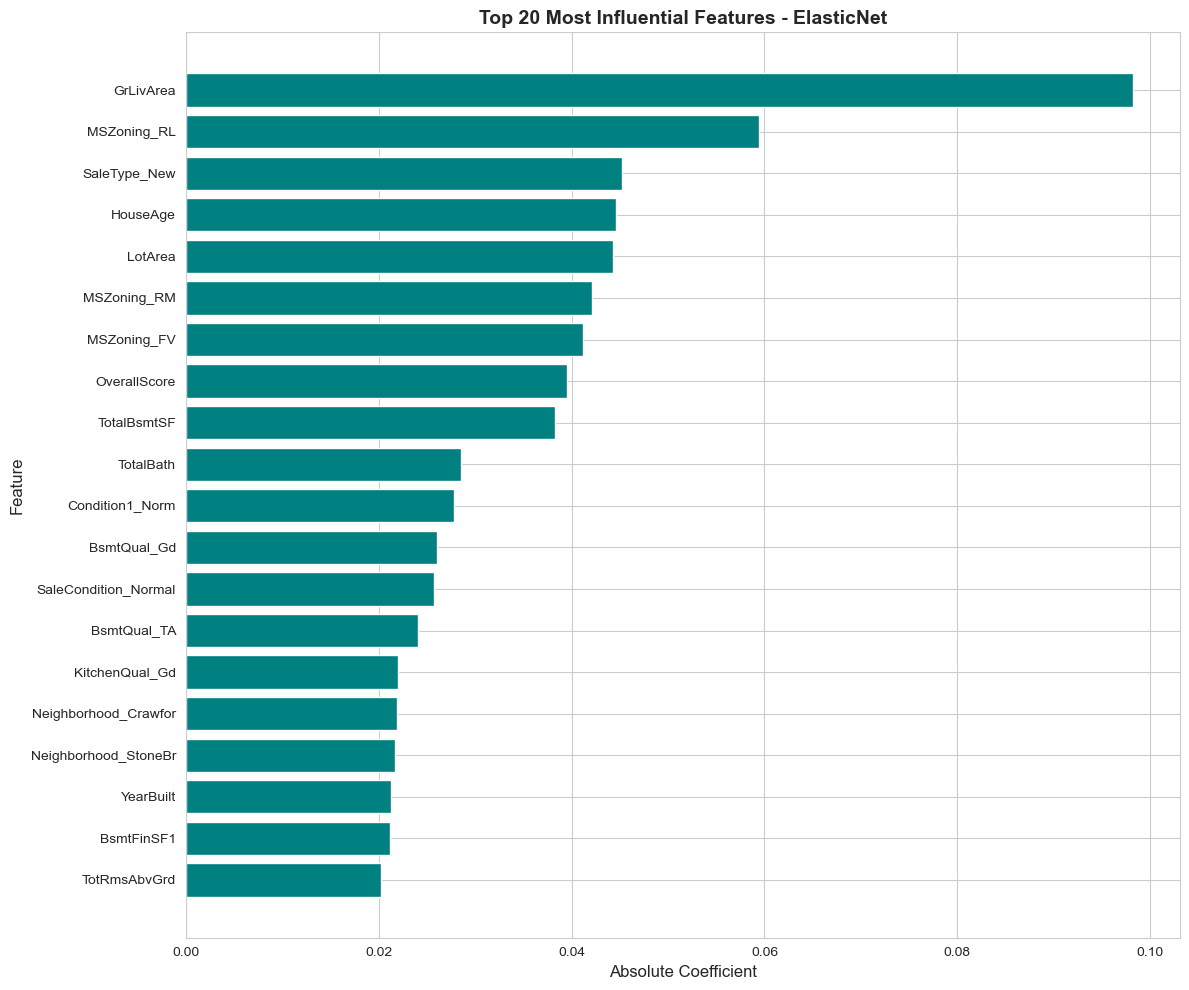

✓ Saved: C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/10_feature_importance.png


In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Ensure folders exist
os.makedirs('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/reports', exist_ok=True)
os.makedirs('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals', exist_ok=True)

print("\n" + "="*60)
print("FEATURE IMPORTANCE / COEFFICIENT ANALYSIS")
print("="*60)

feature_names = X_train.columns

# Detect model type and extract importances
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    importance_label = "Importance Score"
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_)
    importance_label = "Absolute Coefficient"
else:
    raise AttributeError(f"{type(best_model).__name__} does not support feature importance extraction.")

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    importance_label: importances
}).sort_values(importance_label, ascending=False)

# Print top 20 features
print("\nTop 20 Most Influential Features:")
print(feature_importance_df.head(20).to_string(index=False))

# Save CSV
csv_path = 'C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/reports/feature_importance.csv'
feature_importance_df.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

# Plot top 20
top_features = feature_importance_df.head(20)
plt.figure(figsize=(12, 10))
plt.barh(top_features['Feature'], top_features[importance_label], color='teal')
plt.xlabel(importance_label, fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top 20 Most Influential Features - {best_model_name}', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()

fig_path = 'C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/10_feature_importance.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {fig_path}")

In [39]:
print("\n" + "="*60)
print("SAMPLE PREDICTIONS")
print("="*60)

# Select 10 random samples from test set
sample_indices = np.random.choice(X_test.index, size=10, replace=False)
X_sample = X_test.loc[sample_indices]
y_sample_true = y_test.loc[sample_indices]

# Scale and predict
X_sample_scaled = scaler.transform(X_sample)
y_sample_pred = best_model.predict(X_sample_scaled)

# Convert to original scale
y_sample_true_orig = np.expm1(y_sample_true)
y_sample_pred_orig = np.expm1(y_sample_pred)

# Display
print("\nSample Predictions:\n")
results_df = pd.DataFrame({
    'Actual Price': y_sample_true_orig.values,
    'Predicted Price': y_sample_pred_orig,
    'Error': y_sample_true_orig.values - y_sample_pred_orig,
    'Error %': ((y_sample_true_orig.values - y_sample_pred_orig) / y_sample_true_orig.values * 100)
})

for idx, row in results_df.iterrows():
    print(f"House {idx+1}:")
    print(f"  Actual:    ${row['Actual Price']:,.2f}")
    print(f"  Predicted: ${row['Predicted Price']:,.2f}")
    print(f"  Error:     ${row['Error']:,.2f} ({row['Error %']:.1f}%)")
    print()

print("✓ Model successfully predicts house prices!")


SAMPLE PREDICTIONS

Sample Predictions:

House 1:
  Actual:    $40,000.00
  Predicted: $84,008.94
  Error:     $-44,008.94 (-110.0%)

House 2:
  Actual:    $136,000.00
  Predicted: $127,333.04
  Error:     $8,666.96 (6.4%)

House 3:
  Actual:    $93,000.00
  Predicted: $106,541.73
  Error:     $-13,541.73 (-14.6%)

House 4:
  Actual:    $173,500.00
  Predicted: $181,958.22
  Error:     $-8,458.22 (-4.9%)

House 5:
  Actual:    $119,500.00
  Predicted: $114,215.22
  Error:     $5,284.78 (4.4%)

House 6:
  Actual:    $196,000.00
  Predicted: $198,707.95
  Error:     $-2,707.95 (-1.4%)

House 7:
  Actual:    $179,665.00
  Predicted: $214,893.13
  Error:     $-35,228.13 (-19.6%)

House 8:
  Actual:    $113,000.00
  Predicted: $109,176.49
  Error:     $3,823.51 (3.4%)

House 9:
  Actual:    $191,000.00
  Predicted: $242,453.95
  Error:     $-51,453.95 (-26.9%)

House 10:
  Actual:    $197,900.00
  Predicted: $199,753.04
  Error:     $-1,853.04 (-0.9%)

✓ Model successfully predicts house p

In [41]:
print("\n" + "="*60)
print("MODELING SUMMARY")
print("="*60)

summary = f"""
HOUSE PRICE PREDICTION - MODELING RESULTS

DATASET:
  - Total houses: {len(df):,}
  - Training set: {len(X_train):,} houses
  - Test set: {len(X_test):,} houses
  - Features: {X_train.shape[1]}

MODELS EVALUATED:
  1. Linear Regression
  2. Ridge Regression
  3. Lasso Regression
  4. ElasticNet
  5. Random Forest
  6. Gradient Boosting
  7. XGBoost

BEST MODEL: {best_model_name}

TEST SET PERFORMANCE:
  - RMSE (log scale):     {best_metrics['Test_RMSE']:.4f}
  - RMSE (original $):    ${best_metrics['Test_RMSE_Original']:,.2f}
  - MAE (original $):     ${best_metrics['Test_MAE_Original']:,.2f}
  - R² Score:             {best_metrics['Test_R2']:.4f}

CROSS-VALIDATION (5-Fold):
  - Mean RMSE: {cv_scores.mean():.4f}
  - Std Dev: {cv_scores.std():.4f}
  - Model stability: {'Excellent' if cv_scores.std() < 0.02 else 'Good' if cv_scores.std() < 0.05 else 'Fair'}

MODEL INTERPRETATION:
  - R² = {best_metrics['Test_R2']:.1%}: Model explains {best_metrics['Test_R2']:.1%} of variance in house prices
  - Average prediction error: ${best_metrics['Test_MAE_Original']:,.0f}
  - 95% of predictions within: ±${2 * best_metrics['Test_RMSE_Original']:,.0f}

BUSINESS VALUE:
  - Automated house price estimation
  - Fair pricing for buyers and sellers
  - Identify undervalued/overvalued properties
  - Real estate market analysis

FILES SAVED:
  - models/scaler.pkl
  - models/best_model.pkl
  - reports/model_comparison.csv
  - reports/feature_importance.csv (if tree-based model)
  - visuals/07_model_comparison.png
  - visuals/08_prediction_analysis.png
  - visuals/09_cross_validation.png
  - visuals/10_feature_importance.png (if applicable)

READY FOR DEPLOYMENT: YES ✓
"""

print(summary)

# Save summary
with open('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/reports/04_modeling_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✓ Summary saved: reports/04_modeling_summary.txt")


MODELING SUMMARY

HOUSE PRICE PREDICTION - MODELING RESULTS

DATASET:
  - Total houses: 1,458
  - Training set: 1,166 houses
  - Test set: 292 houses
  - Features: 268

MODELS EVALUATED:
  1. Linear Regression
  2. Ridge Regression
  3. Lasso Regression
  4. ElasticNet
  5. Random Forest
  6. Gradient Boosting
  7. XGBoost

BEST MODEL: ElasticNet

TEST SET PERFORMANCE:
  - RMSE (log scale):     0.1215
  - RMSE (original $):    $20,527.15
  - MAE (original $):     $14,382.84
  - R² Score:             0.9124

CROSS-VALIDATION (5-Fold):
  - Mean RMSE: 0.1177
  - Std Dev: 0.0099
  - Model stability: Excellent

MODEL INTERPRETATION:
  - R² = 91.2%: Model explains 91.2% of variance in house prices
  - Average prediction error: $14,383
  - 95% of predictions within: ±$41,054

BUSINESS VALUE:
  - Automated house price estimation
  - Fair pricing for buyers and sellers
  - Identify undervalued/overvalued properties
  - Real estate market analysis

FILES SAVED:
  - models/scaler.pkl
  - models/

In [42]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Load data
df = pd.read_csv('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/data/processed/housing_processed.csv')
X = df.drop(['Id', 'SalePrice', 'SalePrice_Log'], axis=1, errors='ignore')
y = df['SalePrice_Log']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load scaler
with open('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nData loaded: {X_train_scaled.shape[0]} training samples")

HYPERPARAMETER TUNING

Data loaded: 1166 training samples


In [43]:
print("\n" + "="*60)
print("TUNING XGBOOST")
print("="*60)

from xgboost import XGBRegressor

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Use RandomizedSearchCV (faster than GridSearch)
xgb_base = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=20,  # Try 20 random combinations
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\nStarting hyperparameter search... (may take 10-15 minutes)")
random_search.fit(X_train_scaled, y_train)

print(f"\n✓ Hyperparameter search complete!")
print(f"\nBest Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV RMSE: {-random_search.best_score_:.4f}")

# Evaluate on test set
best_tuned_model = random_search.best_estimator_
y_test_pred = best_tuned_model.predict(X_test_scaled)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# Original scale
y_test_orig = np.expm1(y_test)
y_test_pred_orig = np.expm1(y_test_pred)
test_rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))

print(f"\nTest Set Performance:")
print(f"  RMSE (log): {test_rmse:.4f}")
print(f"  RMSE ($):   ${test_rmse_orig:,.2f}")
print(f"  R²:         {test_r2:.4f}")

# Save tuned model
with open('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/models/best_tuned_model.pkl', 'wb') as f:
    pickle.dump(best_tuned_model, f)

print("\n✓ Tuned model saved: models/best_tuned_model.pkl")


TUNING XGBOOST

Starting hyperparameter search... (may take 10-15 minutes)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Hyperparameter search complete!

Best Parameters:
  subsample: 1.0
  n_estimators: 200
  min_child_weight: 1
  max_depth: 3
  learning_rate: 0.05
  colsample_bytree: 0.8

Best CV RMSE: 0.1219

Test Set Performance:
  RMSE (log): 0.1267
  RMSE ($):   $20,438.95
  R²:         0.9047

✓ Tuned model saved: models/best_tuned_model.pkl


In [44]:
print("\n" + "="*60)
print("BASELINE vs TUNED MODEL COMPARISON")
print("="*60)

# Load baseline
with open('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/models/best_model.pkl', 'rb') as f:
    baseline_model = pickle.load(f)

# Predictions
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_pred_tuned = best_tuned_model.predict(X_test_scaled)

# Metrics
from sklearn.metrics import mean_absolute_error

baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

baseline_r2 = r2_score(y_test, y_pred_baseline)
tuned_r2 = r2_score(y_test, y_pred_tuned)

# Original scale
y_pred_baseline_orig = np.expm1(y_pred_baseline)
y_pred_tuned_orig = np.expm1(y_pred_tuned)

baseline_rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_baseline_orig))
tuned_rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_tuned_orig))

baseline_mae_orig = mean_absolute_error(y_test_orig, y_pred_baseline_orig)
tuned_mae_orig = mean_absolute_error(y_test_orig, y_pred_tuned_orig)

# Compare
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Tuned'],
    'RMSE_Log': [baseline_rmse, tuned_rmse],
    'RMSE_Dollar': [baseline_rmse_orig, tuned_rmse_orig],
    'MAE_Dollar': [baseline_mae_orig, tuned_mae_orig],
    'R2_Score': [baseline_r2, tuned_r2]
})

print("\n", comparison.to_string(index=False))

# Calculate improvement
improvement_rmse = ((baseline_rmse - tuned_rmse) / baseline_rmse) * 100
improvement_r2 = ((tuned_r2 - baseline_r2) / baseline_r2) * 100

print(f"\nImprovement with Tuning:")
print(f"  RMSE: {improvement_rmse:.2f}% reduction")
print(f"  R²:   {improvement_r2:.2f}% increase")
print(f"  Dollar savings: ${baseline_rmse_orig - tuned_rmse_orig:,.2f} per prediction")

# Save comparison
comparison.to_csv('C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/reports/baseline_vs_tuned_comparison.csv', index=False)
print("\n✓ Saved: reports/baseline_vs_tuned_comparison.csv")


BASELINE vs TUNED MODEL COMPARISON

    Model  RMSE_Log  RMSE_Dollar   MAE_Dollar  R2_Score
Baseline  0.121519 20527.150486 14382.842041  0.912402
   Tuned  0.126719 20438.953358 14800.572346  0.904746

Improvement with Tuning:
  RMSE: -4.28% reduction
  R²:   -0.84% increase
  Dollar savings: $88.20 per prediction

✓ Saved: reports/baseline_vs_tuned_comparison.csv


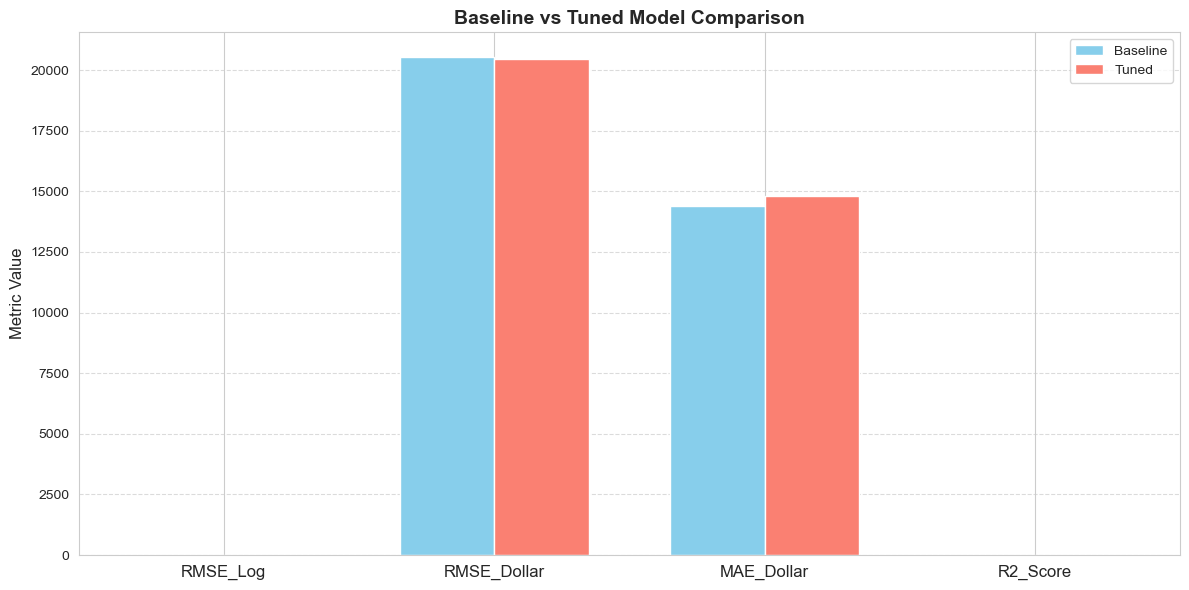


✓ Saved: C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/baseline_vs_tuned_comparison.png


In [56]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['RMSE_Log', 'RMSE_Dollar', 'MAE_Dollar', 'R2_Score']
labels = ['Baseline', 'Tuned']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

# Plot baseline and tuned bars
ax.bar(x - width/2, comparison.loc[0, metrics], width, label='Baseline', color='skyblue')
ax.bar(x + width/2, comparison.loc[1, metrics], width, label='Tuned', color='salmon')

# Labels
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Metric Value", fontsize=12)
ax.set_title("Baseline vs Tuned Model Comparison", fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save figure
fig_path = 'C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/baseline_vs_tuned_comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {fig_path}")

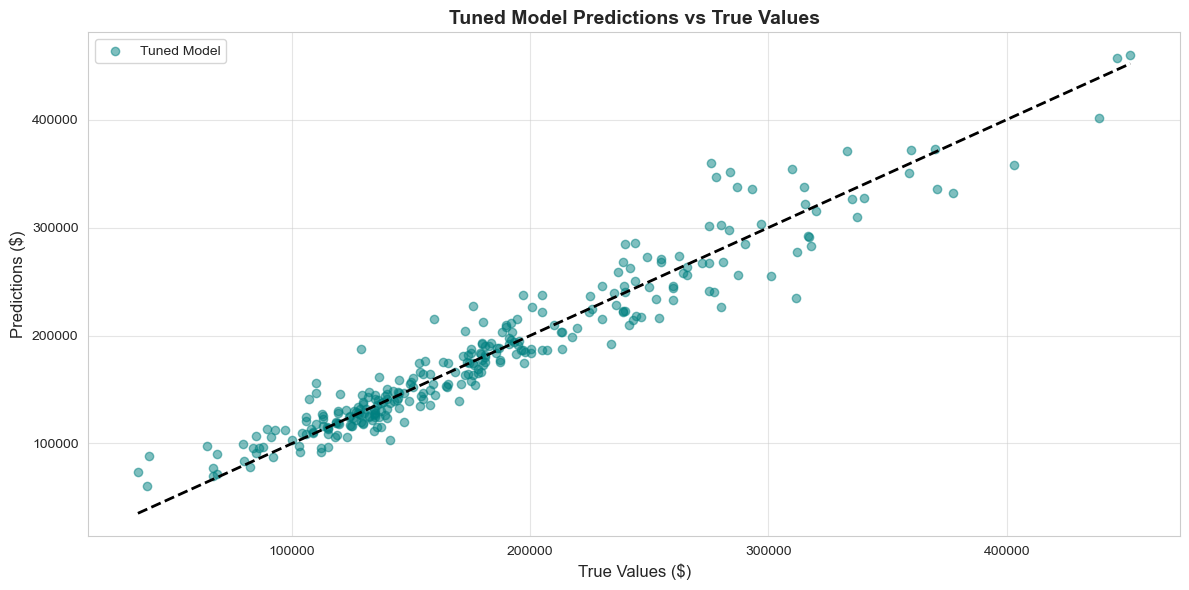

In [57]:
plt.figure(figsize=(12,6))
plt.scatter(y_test_orig, y_pred_tuned_orig, alpha=0.5, color='teal', label='Tuned Model')
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         'k--', lw=2)
plt.xlabel("True Values ($)", fontsize=12)
plt.ylabel("Predictions ($)", fontsize=12)
plt.title("Tuned Model Predictions vs True Values", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
# Save figure
fig_path = 'C:/Users/s.c/Documents/DataScience-Projects/house-price-prediction/visuals/Tuned Model Predictions vs True Values.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()